In [2]:
! pip install pandas numpy scikit-learn matplotlib 


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.ensemble import IsolationForest

df = pd.read_csv('dataset.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [4]:
time_map = {'Day': 1, 'Night': 0}
df['Daytime'] = df['Daytime'].map(time_map)

features = df.drop(columns=['ID', 'Datetime'])

In [5]:
scaler = preprocessing.StandardScaler()
df_scaled = scaler.fit_transform(features)
print(df_scaled.shape)

(4100, 7)


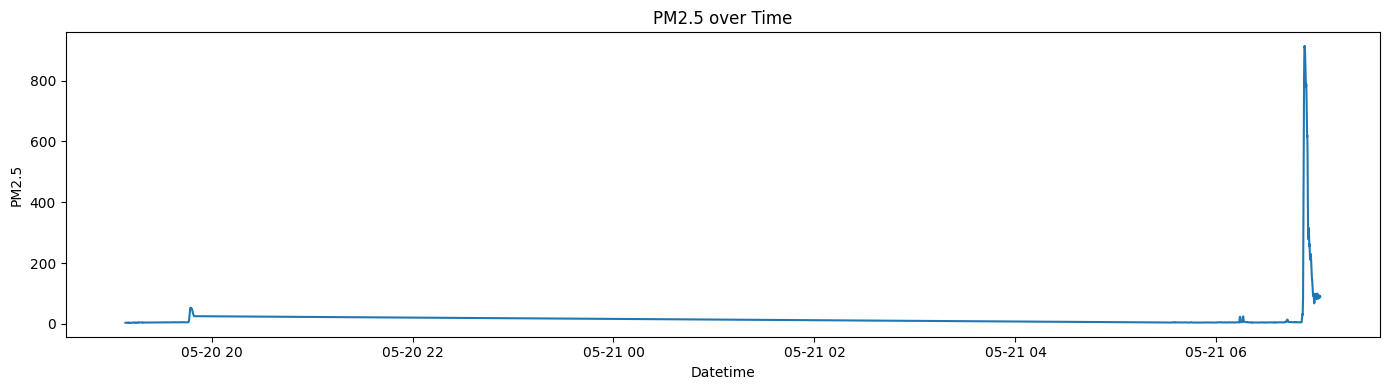

In [6]:
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['PM2.5'])
plt.title('PM2.5 over Time')
plt.xlabel('Datetime')
plt.ylabel('PM2.5')
plt.tight_layout()
plt.show()

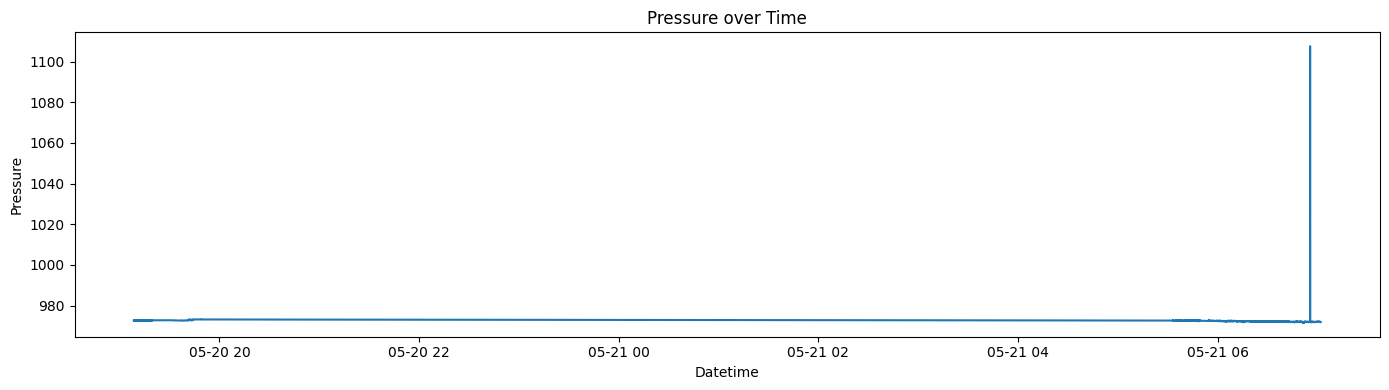

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['Pressure'])
plt.title('Pressure over Time')
plt.xlabel('Datetime')
plt.ylabel('Pressure')
plt.tight_layout()
plt.show()

In [8]:
model = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
model.fit(df_scaled)
df['anomaly'] = model.predict(df_scaled)
df['anomaly'].value_counts()

anomaly
 1    4018
-1      82
Name: count, dtype: int64

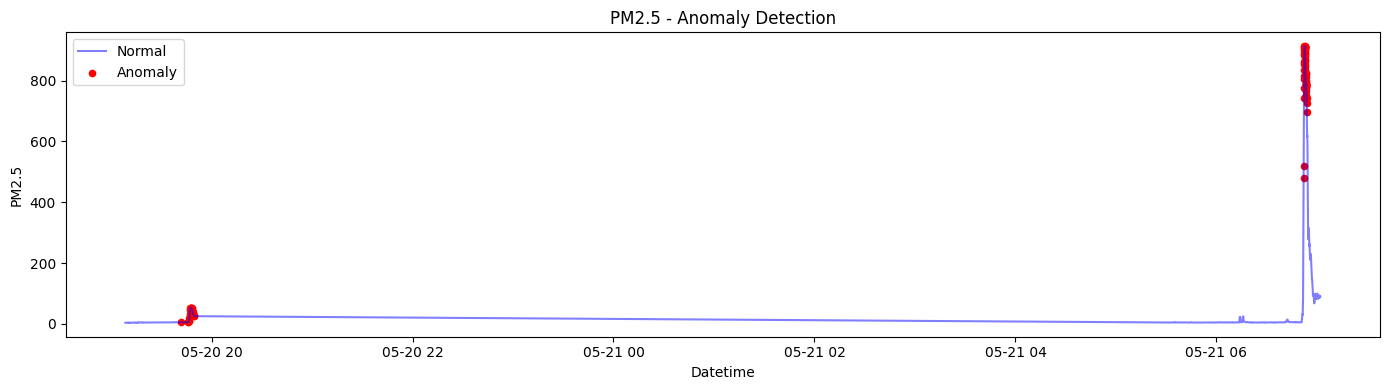

In [9]:
anomalies = df[df['anomaly'] == -1]

plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['PM2.5'], color='blue', alpha=0.5, label='Normal')
plt.scatter(anomalies['Datetime'], anomalies['PM2.5'], color='red', s=20, label='Anomaly')
plt.title('PM2.5 - Anomaly Detection')
plt.xlabel('Datetime')
plt.ylabel('PM2.5')
plt.legend()
plt.tight_layout()
plt.show()

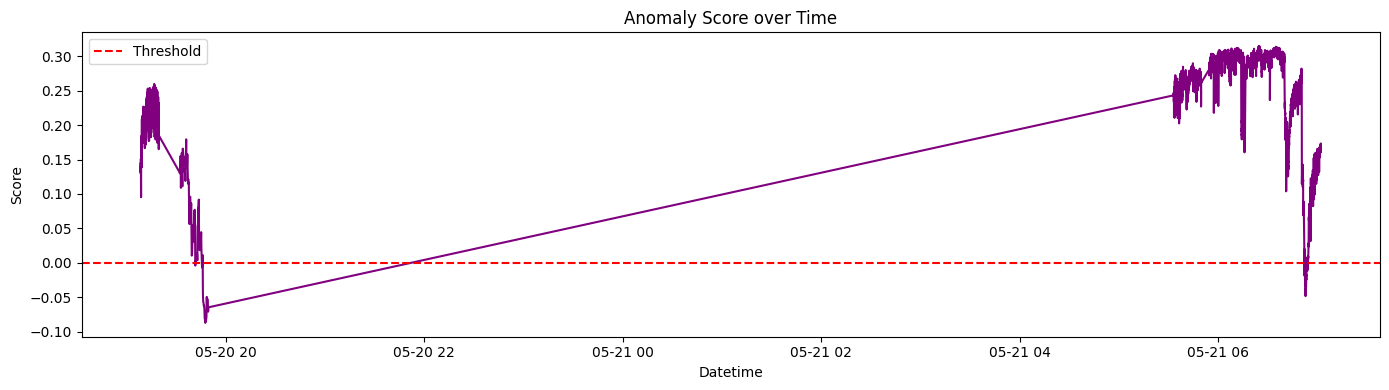

In [10]:
df['anomaly_score'] = model.decision_function(df_scaled)

plt.figure(figsize=(14, 4))
plt.plot(df['Datetime'], df['anomaly_score'], color='purple')
plt.axhline(y=0, color='red', linestyle='--', label='Threshold')
plt.title('Anomaly Score over Time')
plt.xlabel('Datetime')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

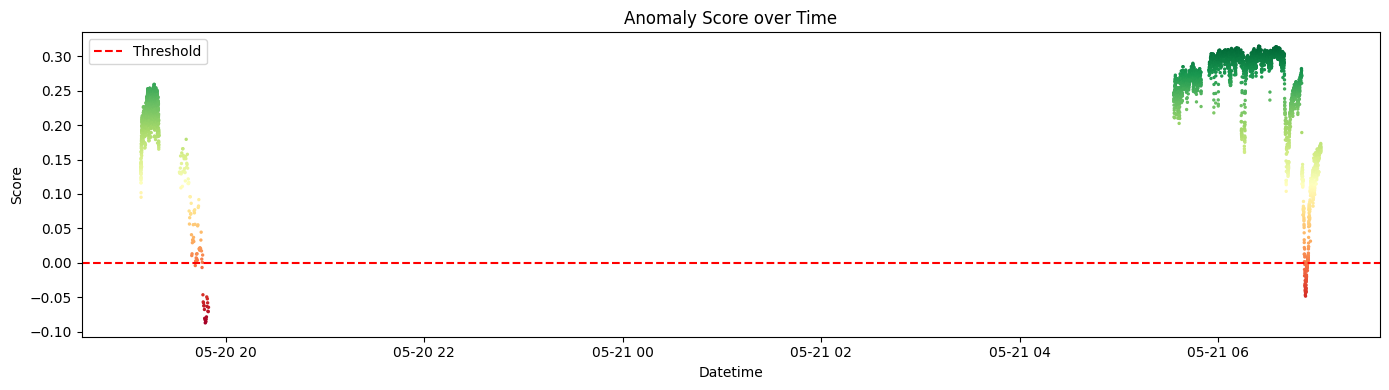

In [11]:
df_plot = df.set_index('Datetime')

plt.figure(figsize=(14, 4))
plt.scatter(df['Datetime'], df['anomaly_score'], 
            c=df['anomaly_score'], cmap='RdYlGn', s=2)
plt.axhline(y=0, color='red', linestyle='--', label='Threshold')
plt.title('Anomaly Score over Time')
plt.xlabel('Datetime')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

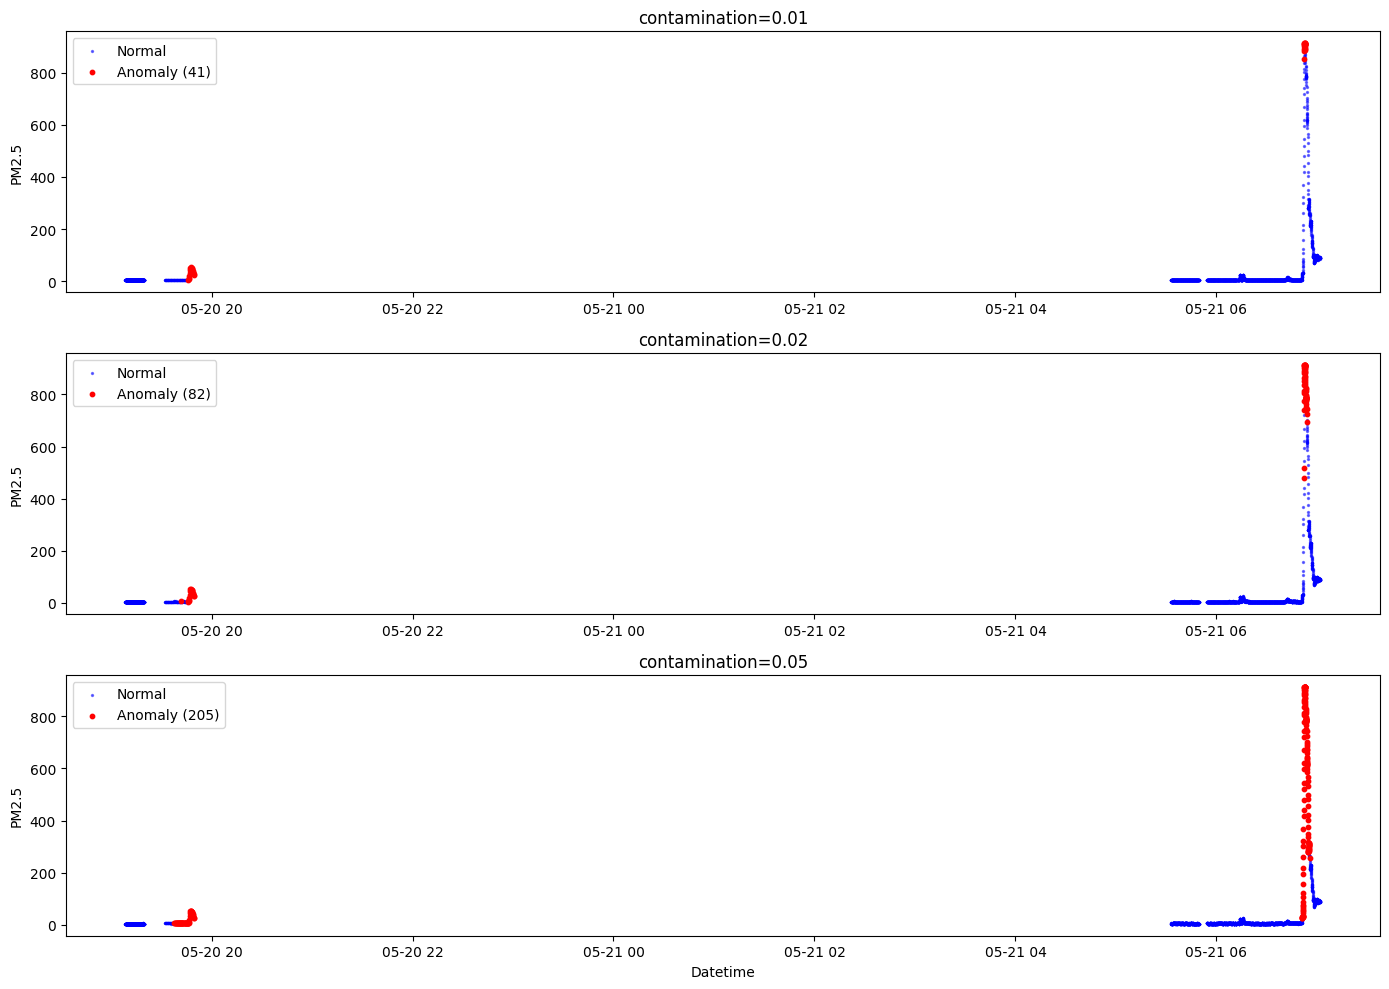

In [12]:
#checking variation across different contamination points
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, cont in zip(axes, [0.01, 0.02, 0.05]):
    m = IsolationForest(n_estimators=200, 
                        contamination=cont, 
                        random_state=42)
    m.fit(df_scaled)
    preds = m.predict(df_scaled)
    
    anomaly_mask = preds == -1
    normal_mask = preds == 1
    
    ax.scatter(df['Datetime'][normal_mask], 
               df['PM2.5'][normal_mask], 
               color='blue', s=2, alpha=0.5, label='Normal')
    ax.scatter(df['Datetime'][anomaly_mask], 
               df['PM2.5'][anomaly_mask], 
               color='red', s=10, label=f'Anomaly ({sum(anomaly_mask)})')
    ax.set_title(f'contamination={cont}')
    ax.set_ylabel('PM2.5')
    ax.legend()

plt.xlabel('Datetime')
plt.tight_layout()
plt.show()

In [13]:
#checking feature wise contribution
normal_rows = df[df['anomaly'] == 1]
anomaly_rows = df[df['anomaly'] == -1]

features = ['Temperature', 'Humidity', 'Pressure', 'Co2 Gas', 'PM2.5', 'PM10']

comparison = pd.DataFrame({
    'Normal Mean': normal_rows[features].mean(),
    'Anomaly Mean': anomaly_rows[features].mean(),
    'Normal Std': normal_rows[features].std(),
    'Anomaly Std': anomaly_rows[features].std()
})

comparison['Difference %'] = ((comparison['Anomaly Mean'] - comparison['Normal Mean']) / comparison['Normal Mean'] * 100).round(2)

comparison

,Normal Mean,Anomaly Mean,Normal Std,Anomaly Std,Difference %
Temperature,25.486715,25.939256,1.547052,1.336228,1.78
Humidity,26.713633,26.915625,4.638943,5.096094,0.76
Pressure,972.447965,972.310524,2.153718,0.549530,-0.01
Co2 Gas,581.080637,808.585366,62.679899,79.934997,39.15
PM2.5,19.822449,612.415854,67.418939,360.570923,2989.51
PM10,28.239174,783.740244,77.642261,469.715424,2675.37


In [14]:
anomaly_report = df[df['anomaly'] == -1][['Datetime', 'Temperature', 
                                          'Humidity', 'Pressure', 
                                          'Co2 Gas', 'PM2.5', 
                                          'PM10', 'anomaly_score']].copy()

anomaly_report = anomaly_report.sort_values('anomaly_score')
anomaly_report.reset_index(drop=True, inplace=True)
print(f"Total anomalies: {len(anomaly_report)}")
anomaly_report.head(20)

Total anomalies: 82


,Datetime,Temperature,Humidity,Pressure,Co2 Gas,PM2.5,PM10,anomaly_score
0,2019-05-20 19:47:37,23.745485,34.782675,973.229002,1015,51.2,65.6,-0.087370
1,2019-05-20 19:47:48,23.730170,34.862757,973.177447,1014,50.8,64.2,-0.086089
2,2019-05-20 19:47:59,23.719960,34.942846,973.189618,987,51.5,66.8,-0.085321
3,2019-05-20 19:47:27,23.750590,34.617425,973.208953,1011,53.5,66.3,-0.082767
4,2019-05-20 19:48:09,23.694434,34.922744,973.178158,968,50.8,68.5,-0.081997
5,2019-05-20 19:47:16,23.771010,34.557369,973.184607,982,51.8,63.5,-0.080730
6,2019-05-20 19:48:20,23.694434,35.037903,973.178158,965,48.1,64.4,-0.078671
7,2019-05-20 19:49:24,23.638279,35.543316,973.286960,943,27.2,35.0,-0.071049
8,2019-05-20 19:49:13,23.643384,35.448231,973.183154,938,29.8,38.1,-0.070349
9,2019-05-20 19:47:06,23.791430,34.367077,973.216112,912,44.6,52.4,-0.067889


In [15]:
#final block to print pretty report 
def assign_severity(score):
    if score < -0.07:
        return 'High'
    elif score < -0.05:
        return 'Medium'
    else:
        return 'Low'

anomaly_report = df[df['anomaly'] == -1][['Datetime', 'Temperature', 
                                          'Humidity', 'Pressure', 
                                          'Co2 Gas', 'PM2.5', 
                                          'PM10', 'anomaly_score']].copy()

anomaly_report = anomaly_report.sort_values('anomaly_score')
anomaly_report.reset_index(drop=True, inplace=True)
anomaly_report['severity'] = anomaly_report['anomaly_score'].apply(assign_severity)

print(f"Total anomalies: {len(anomaly_report)}")
print(f"\nSeverity breakdown:")
print(anomaly_report['severity'].value_counts())
print("\n")
anomaly_report.head(20)

Total anomalies: 82

Severity breakdown:
severity
Low       64
High       9
Medium     9
Name: count, dtype: int64




,Datetime,Temperature,Humidity,Pressure,Co2 Gas,PM2.5,PM10,anomaly_score,severity
0,2019-05-20 19:47:37,23.745485,34.782675,973.229002,1015,51.2,65.6,-0.087370,High
1,2019-05-20 19:47:48,23.730170,34.862757,973.177447,1014,50.8,64.2,-0.086089,High
2,2019-05-20 19:47:59,23.719960,34.942846,973.189618,987,51.5,66.8,-0.085321,High
3,2019-05-20 19:47:27,23.750590,34.617425,973.208953,1011,53.5,66.3,-0.082767,High
4,2019-05-20 19:48:09,23.694434,34.922744,973.178158,968,50.8,68.5,-0.081997,High
5,2019-05-20 19:47:16,23.771010,34.557369,973.184607,982,51.8,63.5,-0.080730,High
6,2019-05-20 19:48:20,23.694434,35.037903,973.178158,965,48.1,64.4,-0.078671,High
7,2019-05-20 19:49:24,23.638279,35.543316,973.286960,943,27.2,35.0,-0.071049,High
8,2019-05-20 19:49:13,23.643384,35.448231,973.183154,938,29.8,38.1,-0.070349,High
9,2019-05-20 19:47:06,23.791430,34.367077,973.216112,912,44.6,52.4,-0.067889,Medium


In [ ]:
!pip install optuna

     ------------------------------------ 419.5/419.5 kB 688.9 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import optuna
from sklearn.metrics import silhouette_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    contamination = trial.suggest_float('contamination', 0.01, 0.1)
    max_features = trial.suggest_float('max_features', 0.5, 1.0)
    

    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        max_features=max_features,
        random_state=42
    )
    
    preds = model.fit_predict(df_scaled)
    
    # Silhouette score needs at least 2 unique labels
    if len(set(preds)) < 2:
        return -1
    
    score = silhouette_score(df_scaled, preds)
    return score

# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Best parameters:")
print(study.best_params)
print(f"\nBest silhouette score: {study.best_value:.4f}")


c:\Users\TE497693\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best parameters:
{'n_estimators': 78, 'contamination': 0.021614404694483343, 'max_features': 0.711390953189645}

Best silhouette score: 0.7473


In [ ]:
#applying best param on model
best_params = study.best_params

final_model = IsolationForest(
    n_estimators=best_params['n_estimators'],
    contamination=best_params['contamination'],
    max_features=best_params['max_features'],
    random_state=42
)

final_model.fit(df_scaled)
df['anomaly'] = final_model.predict(df_scaled)
df['anomaly_score'] = final_model.decision_function(df_scaled)

print(df['anomaly'].value_counts())

anomaly
 1    4011
-1      89
Name: count, dtype: int64


In [19]:
!pip install shap

     ------------------------------------ 554.9/554.9 kB 791.6 kB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 5.2 MB/s eta 0:00:00
     ---------------------------------------- 38.1/38.1 MB 3.6 MB/s eta 0:00:00
  Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


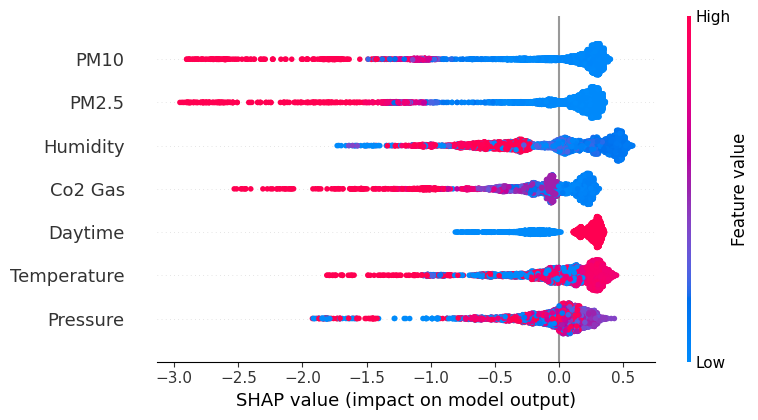

In [20]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(df_scaled)

# Summary plot - overall feature importance
shap.summary_plot(shap_values, df_scaled, 
                  feature_names=['Temperature', 'Humidity', 'Pressure', 
                                'Co2 Gas', 'PM2.5', 'PM10', 'Daytime'])